In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the dataset
url = url = "https://raw.githubusercontent.com/CunyLaguardiaDataAnalytics/datasets/master/2014-15_To_2016-17_School-_Level_NYC_Regents_Report_For_All_Variables.csv"

df = pd.read_csv(url)

In [ ]:
df.head(5)

,School DBN,School Name,School Level,Regents Exam,Year,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above,Number Scoring CR,Percent Scoring CR
0,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Common Core Algebra,2017,4,s,s,s,s,s,s,s,na,na
1,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2015,16,77.9,1,6.3,15,93.8,7,43.8,na,na
2,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2016,9,74,1,11.1,8,88.9,2,22.2,na,na
3,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2016,3,s,s,s,s,s,s,s,na,na
4,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2017,2,s,s,s,s,s,s,s,na,na


In [ ]:
df.tail()


,School DBN,School Name,School Level,Regents Exam,Year,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above,Number Scoring CR,Percent Scoring CR
212326,84X717,Icahn Charter School,K-8,Living Environment,2016,8,s,s,s,s,s,s,s,na,na
212327,84X717,Icahn Charter School,K-8,Living Environment,2016,5,s,s,s,s,s,s,s,na,na
212328,84X717,Icahn Charter School,K-8,Living Environment,2017,6,s,s,s,s,s,s,s,na,na
212329,84X717,Icahn Charter School,K-8,Living Environment,2017,4,s,s,s,s,s,s,s,na,na
212330,84X717,Icahn Charter School,K-8,U.S. History and Government,2015,1,s,s,s,s,s,s,s,na,na


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 212331 entries, 0 to 212330
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype 
---  ------                       --------------   ----- 
 0   School DBN                   212331 non-null  object
 1   School Name                  212331 non-null  object
 2   School Level                 212331 non-null  object
 3   Regents Exam                 212321 non-null  object
 4   Year                         212331 non-null  int64 
 5   Total Tested                 212331 non-null  int64 
 6   Mean Score                   212331 non-null  object
 7   Number Scoring Below 65      212331 non-null  object
 8   Percent Scoring Below 65     212331 non-null  object
 9   Number Scoring 65 or Above   212331 non-null  object
 10  Percent Scoring 65 or Above  212331 non-null  object
 11  Number Scoring 80 or Above   212331 non-null  object
 12  Percent Scoring 80 or Above  212331 non-null  object
 13  Number Scoring

In [ ]:
df.describe()

,Year,Total Tested
count,212331.000000,212331.000000
mean,2015.956069,49.364200
std,0.799726,93.023576
min,2015.000000,1.000000
25%,2015.000000,5.000000
50%,2016.000000,20.000000
75%,2017.000000,57.000000
max,2017.000000,1729.000000


Data Cleaning: Convert 'Mean Score' to numeric, handling suppressed 's' values

In [ ]:
df['Mean Score'] = pd.to_numeric(df['Mean Score'], errors='coerce')
df_clean = df.dropna(subset=['Mean Score'])

Find the school with the high score

In [ ]:
df_clean['Mean Score'].max()

98.7

In [ ]:
row_details = df.loc[df['Mean Score'].idxmax()]
print(row_details)

School DBN                                                                10X696
School Name                    High School of American Studies at Lehman College
School Level                                                         High school
Regents Exam                                         U.S. History and Government
Year                                                                        2017
Total Tested                                                                  15
Mean Score                                                                  98.7
Number Scoring Below 65                                                        0
Percent Scoring Below 65                                                       0
Number Scoring 65 or Above                                                    15
Percent Scoring 65 or Above                                                  100
Number Scoring 80 or Above                                                    15
Percent Scoring 80 or Above 

School with the lowest Score

In [ ]:
df_clean['Mean Score'].min()

15.0

In [ ]:
row_details = df.loc[df['Mean Score'].idxmin()]
print(row_details)

School DBN                                                          16K498
School Name                    Brooklyn High School for Law and Technology
School Level                                                   High school
Regents Exam                                           Common Core English
Year                                                                  2015
Total Tested                                                            12
Mean Score                                                            15.0
Number Scoring Below 65                                                 12
Percent Scoring Below 65                                               100
Number Scoring 65 or Above                                               0
Percent Scoring 65 or Above                                              0
Number Scoring 80 or Above                                               0
Percent Scoring 80 or Above                                              0
Number Scoring CR        

Filter for two specific schools (using School Name)

In [ ]:
school1 = "Stuyvesant High School"
school2 = "Brooklyn Technical High School"
comparison_df = df_clean[df_clean['School Name'].isin([school1, school2])]


In [ ]:
print(comparison_df)

       School DBN                     School Name School Level  \
1511       02M475          Stuyvesant High School  High school   
1512       02M475          Stuyvesant High School  High school   
1513       02M475          Stuyvesant High School  High school   
1514       02M475          Stuyvesant High School  High school   
1515       02M475          Stuyvesant High School  High school   
...           ...                             ...          ...   
172072     13K430  Brooklyn Technical High School  High school   
172073     13K430  Brooklyn Technical High School  High school   
172074     13K430  Brooklyn Technical High School  High school   
172075     13K430  Brooklyn Technical High School  High school   
172076     13K430  Brooklyn Technical High School  High school   

                       Regents Exam  Year  Total Tested  Mean Score  \
1511          Algebra2/Trigonometry  2015           875        92.9   
1512          Algebra2/Trigonometry  2016           792        93

Visualization: Compare Mean Scores by Exam

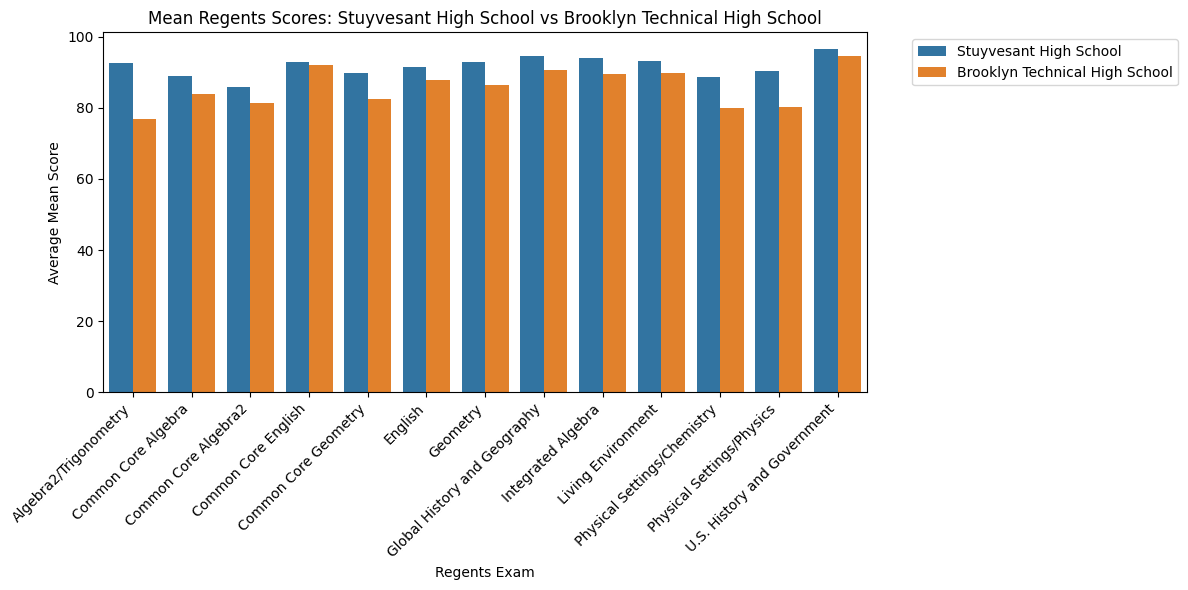

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(data=comparison_df, x='Regents Exam', y='Mean Score', hue='School Name', errorbar=None)
plt.title(f'Mean Regents Scores: {school1} vs {school2}')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Average Mean Score')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

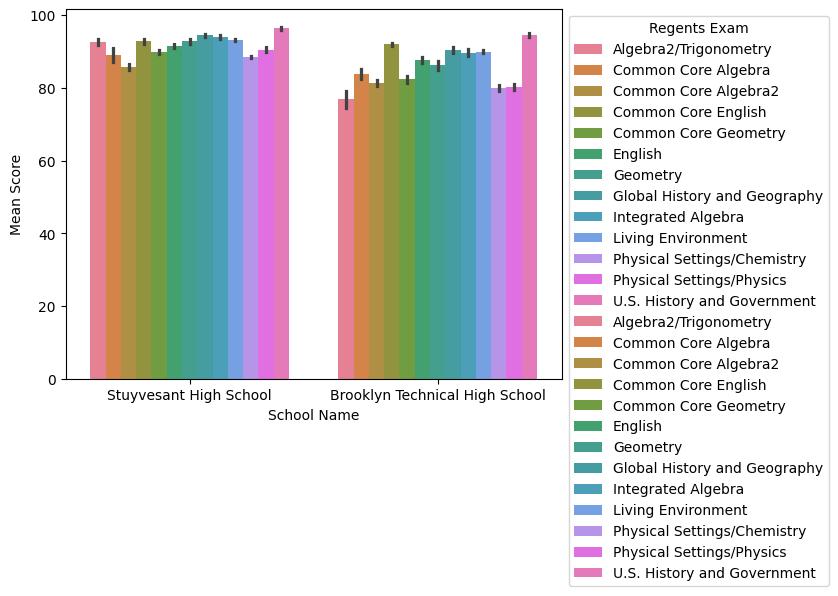

In [ ]:
# Barplot to show the mean score of Regents Exam
sns.barplot(x='School Name',y='Mean Score',data=comparison_df,hue='Regents Exam')
ax = sns.barplot(x='School Name',y='Mean Score',data=comparison_df,hue='Regents Exam')
sns.move_legend(
    ax,
    "upper left",
    # Location string
    bbox_to_anchor=(1, 1) # Coordinates for fine-grained control
    )

<Axes: xlabel='School Name', ylabel='Mean Score'>

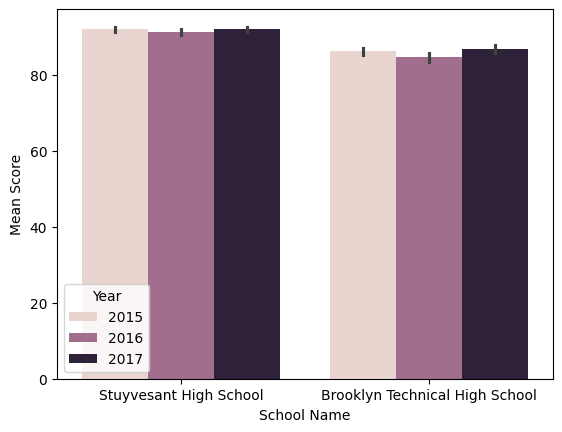

In [ ]:
# Barplot to show the mean score of each year
sns.barplot(x='School Name',y='Mean Score',data=comparison_df,hue='Year')

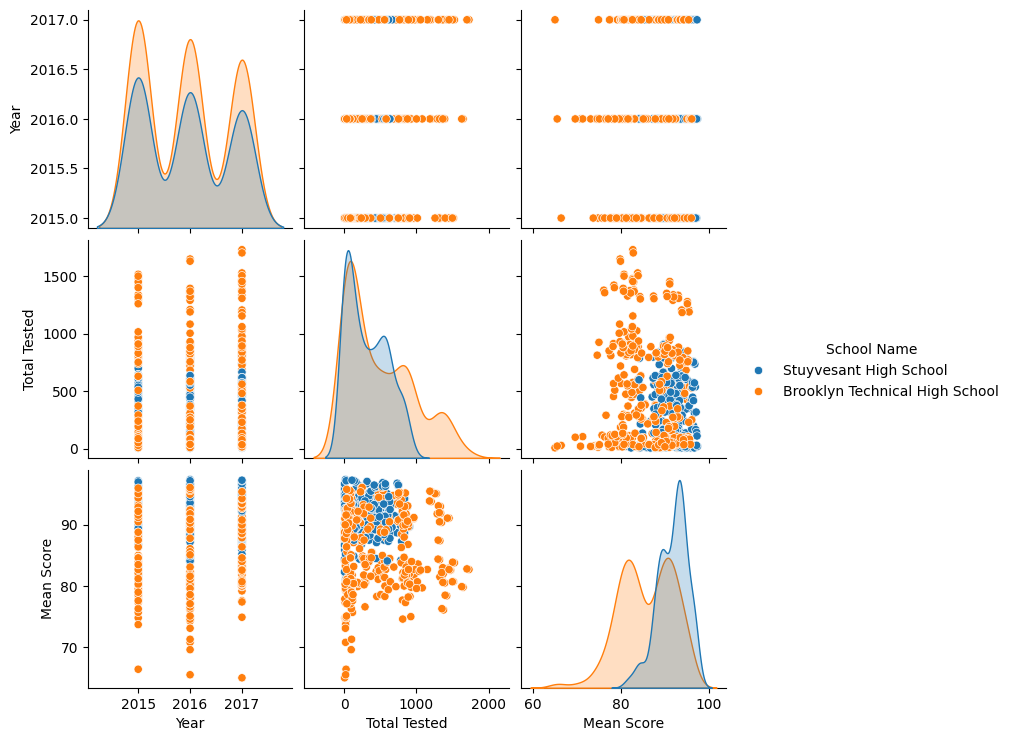

In [ ]:
sns.pairplot(comparison_df,hue='School Name')

**Conclusion:**

Stuyvesant shows a slight edge in top-end Mean Scores (reaching 93.9+ in Math), Brooklyn Tech shows dominant resulut in Humanity (U.S. History).

Both of these schools ara good Schools in terms of academics, with average scores above 80 to mid 90. we can say that both of these schools are performance Schools.